Logistic Regression - Binary

In [ ]:

import pandas as pd
from matplotlib import pyplot as plt
# %matplotlib inline
#"%matplotlib inline" will make your plot outputs appear and be stored within the notebook.

df = pd.read_csv("insurance_data.csv")
df.head()


,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


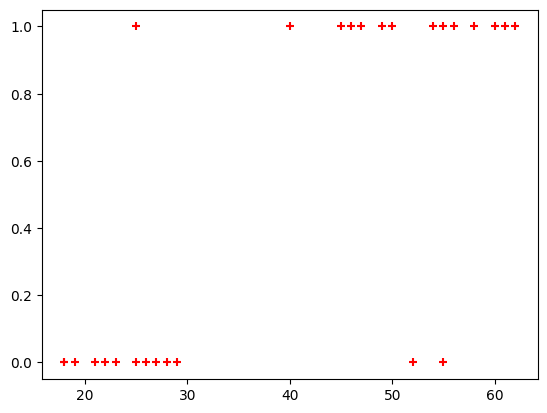

In [ ]:
plt.scatter(df.age,df.bought_insurance,marker='+',color='red')

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df[['age']],df.bought_insurance,train_size=0.9,random_state=10)


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(X_train, y_train)


LogisticRegression()

In [ ]:
y_predicted = model.predict(X_test)
y_predicted

array([1, 1, 0])

In [ ]:
model.score(X_test,y_test)


1.0

In [ ]:
model.predict_proba(X_test)

array([[0.06470655, 0.93529345],
       [0.10327333, 0.89672667],
       [0.92775258, 0.07224742]])

In [ ]:
y_predicted = model.predict([[60]])
y_predicted

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

In [ ]:
#model.coef_ indicates value of m in y=m*x + b equation
model.coef_

#model.intercept_ indicates value of b in y=m*x + b equation
model.intercept_

#Lets defined sigmoid function now and do the math with hand
import math
def sigmoid(x):
  return 1 / (1 + math.exp(-x))

def prediction_function(age):
   z = 0.127 * age - 4.973 # 0.12740563 ~ 0.0127 and -4.97335111 ~ -4.97
   y = sigmoid(z)
   return y

age = 35
prediction_function(age)

#0.37<0.5, will not purchase the insurance

0.3709834769552775

Logistic Regression - Multi

In [ ]:
# -*- coding: utf-8 -*-

# Import necessary libraries
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn import metrics
import matplotlib.pyplot as plt

# Load the Iris dataset
iris =  pd.read_csv("iris (1).csv")
iris.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
X=iris.drop('species',axis='columns')# Features (sepal length, sepal width, petal length, petal width)
y = iris.species # Target labels (0: Setosa, 1: Versicolor, 2: Virginica)

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Multinomial Logistic Regression model
# Use 'multinomial' for multi-class classification and 'lbfgs' solver
model = LogisticRegression(multi_class='multinomial')

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
# Calculate the accuracy of the model on the test data
accuracy = accuracy_score(y_test, y_pred)

# Display the accuracy
print(f"Accuracy of the Multinomial Logistic Regression model on the test set: {accuracy:.2f}")


Accuracy of the Multinomial Logistic Regression model on the test set: 1.00


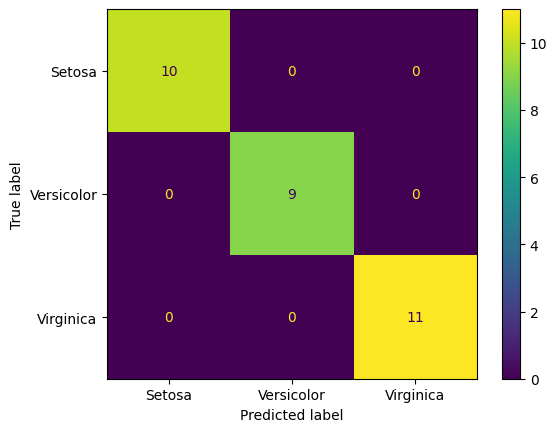

In [ ]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ["Setosa", "Versicolor", "Virginica"])

cm_display.plot()
plt.show()

Logistic Regression - Binary - HR

In [ ]:
df=pd.read_csv("HR_comma_sep.csv")

df.head()

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [ ]:
df.groupby('left').mean(numeric_only=True)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


In [ ]:
df['left'].value_counts()

,count
left,
0,11428
1,3571


In [ ]:
df1=pd.get_dummies(df, columns=['salary', 'Department'])
df1=df1.drop('left', axis='columns')

<Axes: xlabel='salary'>

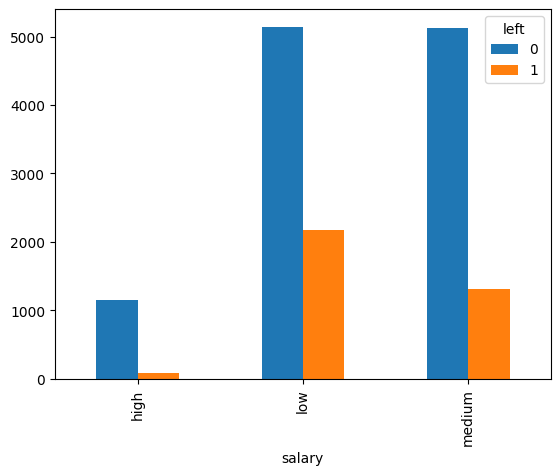

In [ ]:
import matplotlib.pyplot as plt

pd.crosstab(df.salary, df.left).plot(kind='bar')

<Axes: xlabel='Department'>

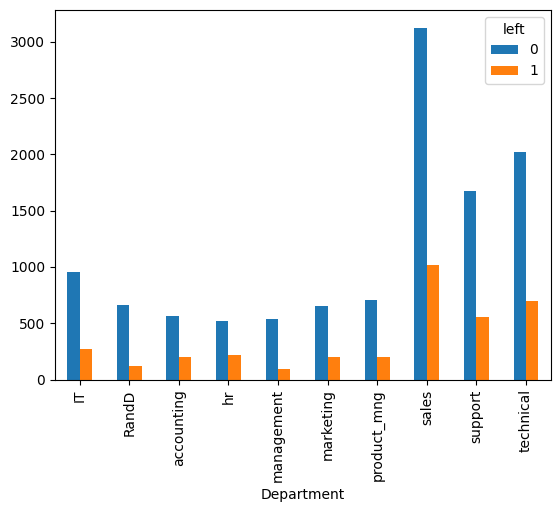

In [ ]:
pd.crosstab(df.Department, df.left).plot(kind='bar')

In [ ]:
df.groupby('left')['satisfaction_level'].mean()

,satisfaction_level
left,
0,0.666810
1,0.440098


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df1, df['left'], test_size=0.2, random_state=10)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate and print accuracy
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy:.4f}")


Model Accuracy: 0.7853


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression - Multi - ZOO

In [ ]:
df=pd.read_csv("zoo-data.csv")

In [ ]:
df1=pd.read_csv("zoo-class-type.csv")

In [ ]:
df.head()

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [ ]:
df1.head()

,Class_Number,Number_Of_Animal_Species_In_Class,Class_Type,Animal_Names
0,1,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,..."
1,2,20,Bird,"chicken, crow, dove, duck, flamingo, gull, haw..."
2,3,5,Reptile,"pitviper, seasnake, slowworm, tortoise, tuatara"
3,4,13,Fish,"bass, carp, catfish, chub, dogfish, haddock, h..."
4,5,4,Amphibian,"frog, frog, newt, toad"


In [ ]:
df=df.drop('animal_name', axis='columns')

In [ ]:
from sklearn.model_selection import train_test_split

df2=df.drop('class_type', axis=1)
X_train, X_test, Y_train, Y_test=train_test_split(df2, df['class_type'], test_size=0.2, random_state=42)

print(Y_test)

84    1
55    1
66    1
67    1
45    1
39    6
22    1
44    1
10    1
0     1
18    4
30    6
97    6
33    2
77    7
4     1
93    1
78    2
12    4
31    1
76    3
Name: class_type, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()

model.fit(X_train, Y_train)

LogisticRegression()

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
accuracy=model.score(X_test, Y_test) #it takes X, predicts Y and then compares y_pred with Y test
accuracy

0.9523809523809523

In [ ]:
accuracy=accuracy_score(y_pred, Y_test)
accuracy

0.9523809523809523

In [ ]:
df.isnull().sum()

,0
hair,0
feathers,0
eggs,0
milk,0
airborne,0
aquatic,0
predator,0
toothed,0
backbone,0
breathes,0


In [ ]:
df.value_counts()

hair  feathers  eggs  milk  airborne  aquatic  predator  toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  class_type
1     0         0     1     0         0        1         1        1         1         0         0     4     1     0         1        1             10
                                               0         1        1         1         0         0     4     1     0         1        1              6
0     0         1     0     0         1        1         1        1         0         0         1     0     1     0         0        4              5
1     0         0     1     0         0        0         1        1         1         0         0     4     1     1         1        1              4
0     1         1     0     1         0        0         0        1         1         0         0     2     1     0         0        2              4
                                                                                                                  1         0        2              3
                                      1        1         0        1         1         0         0     2     1     0         0        2              3
      0         1     0     0         1        1         1        1         0         0         1     0     1     0         1        4              3
                                               0         1        1         0         0         1     0     1     0         0        4              3
                                      0        0         0        0         1         0         0     6     0     0         0        6              2
                                      1        1         0        0         0         0         0     6     0     0         0        7              2
      1         1     0     1         0        1         0        1         1         0         0     2     1     0         0        2              2
1     0         0     1     0         0        0         1        1         1         0         0     4     1     0         0        1              2
0     0         1     0     0         0        0         0        0         1         0         0     0     0     0         0        7              2
                0     1     0         1        1         1        1         1         0         1     0     1     0         1        1              2
1     0         0     1     0         0        1         1        1         1         0         0     4     1     0         0        1              2
                            1         0        0         1        1         1         0         0     2     1     0         0        1              2
                1     0     1         0        0         0        0         1         0         0     6     0     0         0        6              2
                0     1     0         0        1         1        1         1         0         0     4     0     0         1        1              2
0     0         1     0     0         0        1         1        1         1         1         0     0     1     0         0        3              1
                                                                                      0         0     4     1     0         0        3              1
                                                                                                      0     1     0         0        3              1
                                      1        0         1        1         0         0         1     0     1     1         0        4              1
                                      0        1         0        0         0         0         0     0     0     0         0        7              1
                0     0     0         0        1         0        0         1         1         0     8     1     0         0        7              1
                                      1        1         1        1         0         1         0     0   

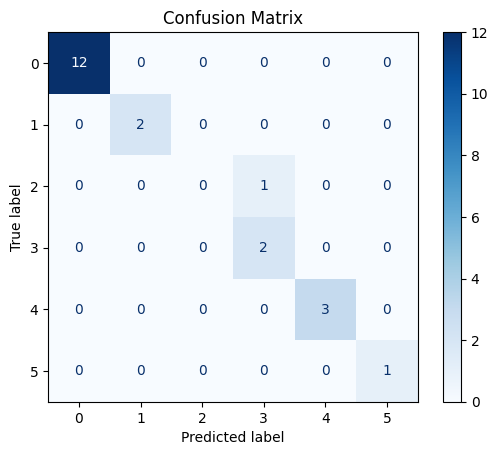

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(Y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()